In [1]:

# CYBERPATH v2  : (ML based RECOMMENDATION SYSTEM)

# This notebook builds an independent, supervised machine learning
# recommendation system trained on synthetic student-machine relevance data.
#
# It is SEPARATE from the v1 system (recommender.ipynb), which remains
# unchanged and continues to use dataset_final.csv.
# v2 uses the corrected dataset (dataset_v2_ai_clean.csv) and trains two
# supervised ranking models for comparison: Random Forest and XGBoost.

# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Set up paths 
BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data', 'dataset_v2_ai_clean.csv')
MODELS_DIR_V2 = os.path.join(BASE_DIR, 'saved_models', 'ai_recommender')

# Creating the v2 models folder 
os.makedirs(MODELS_DIR_V2, exist_ok=True)
os.makedirs(os.path.join(MODELS_DIR_V2, 'plots'), exist_ok=True)

print(f"BASE_DIR:       {BASE_DIR}")
print(f"DATA_PATH:      {DATA_PATH}")
print(f"MODELS_DIR_V2:  {MODELS_DIR_V2}")
print(f"\nDataset file exists: {os.path.exists(DATA_PATH)}")
print(f"v2 folder created:   {os.path.exists(MODELS_DIR_V2)}")

BASE_DIR:       c:\curtin\project new\Vuln Recommendation system
DATA_PATH:      c:\curtin\project new\Vuln Recommendation system\data\dataset_v2_ai_clean.csv
MODELS_DIR_V2:  c:\curtin\project new\Vuln Recommendation system\saved_models\ai_recommender

Dataset file exists: True
v2 folder created:   True


In [2]:
# loadinf dataset and checking basics

df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))

# checking for any missing values
print("\nmissing:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# checking distributions of main fields
print("\ndifficulty:")
print(df['Difficulty'].value_counts())

print("\nattack category:")
print(df['Attack_Category'].value_counts())

print("\nos:")
print(df['OS'].value_counts())

print("\nestimated time:")
print(df['Estimated_Time'].value_counts())

#  unique learning objectives checking
all_objs = []
for s in df['Learning_Objectives'].dropna():
    all_objs.extend([x.strip() for x in str(s).split(';') if x.strip()])
print("\nunique learning objectives:", len(set(all_objs)))

# first 3 rows checking
df[['Machine_Name', 'Difficulty', 'Attack_Category', 'OS', 'Estimated_Time']].head(3)

shape: (305, 18)
columns: ['Machine_ID', 'Machine_Name', 'Platform', 'Platform_ID', 'OS', 'OS_Detail', 'Difficulty', 'Difficulty_Numeric', 'Attack_Category', 'Attack_Category_Detail', 'Vulnerability_Type', 'Kill_Chain_Stages', 'Skills_Required', 'Learning_Objectives', 'Estimated_Time', 'Estimated_Time_Hours', 'Attack_Path_Length', 'Entry_Point']

missing:
OS_Detail    67
dtype: int64

difficulty:
Difficulty
Medium    159
Hard      106
Easy       40
Name: count, dtype: int64

attack category:
Attack_Category
Web Exploitation              190
Network Exploitation          107
Binary Exploitation             4
Mixed (Web + Network)           3
Cryptographic Exploitation      1
Name: count, dtype: int64

os:
OS
Linux      303
FreeBSD      1
Windows      1
Name: count, dtype: int64

estimated time:
Estimated_Time
2-3 hours    140
1-2 hours    103
3-4 hours     43
4+ hours      11
<1 hour        8
Name: count, dtype: int64

unique learning objectives: 99


,Machine_Name,Difficulty,Attack_Category,OS,Estimated_Time
0,LAMPSecurity CTF 4,Easy,Web Exploitation,Linux,1-2 hours
1,LAMPSecurity CTF 5,Easy,Web Exploitation,Linux,2-3 hours
2,LAMPSecurity CTF 7,Easy,Web Exploitation,Linux,2-3 hours


In [3]:
sample = str(df['Kill_Chain_Stages'].iloc[0])
print("sample:", sample)
print("contains arrow:", '→' in sample)

sample: Recon → Exploitation → Credential Access → Lateral Movement → Privilege Escalation
contains arrow: True


In [4]:
# encodeing machines into numeric features for the ml model

from sklearn.preprocessing import MultiLabelBinarizer

# difficulty converting to number
diff_map = {'Easy': 1, 'Medium': 2, 'Hard': 3}
df['diff_num'] = df['Difficulty'].map(diff_map)

# counting kill chain stages per machine
def count_chain_stages(s):
    if pd.isna(s): return 0
    return len([p for p in str(s).split('→') if p.strip()])

df['kill_chain_count'] = df['Kill_Chain_Stages'].apply(count_chain_stages)
print("kill chain count - min/max/mean:",
      df['kill_chain_count'].min(),
      df['kill_chain_count'].max(),
      round(df['kill_chain_count'].mean(), 2))

# attack category () (one hot)
attack_cat = pd.get_dummies(df['Attack_Category'], prefix='cat').astype(int)

# os - (one hot)
os_cat = pd.get_dummies(df['OS'], prefix='os').astype(int)

# learning objectives - (multi hot)
def split_objs(s):
    if pd.isna(s): return []
    return [x.strip() for x in str(s).split(';') if x.strip()]

obj_lists = df['Learning_Objectives'].apply(split_objs)
mlb = MultiLabelBinarizer()
obj_matrix = mlb.fit_transform(obj_lists)
obj_df = pd.DataFrame(obj_matrix, columns=['obj_' + c for c in mlb.classes_])

# final machine feature matrix
machine_features = pd.concat([
    df[['diff_num', 'Estimated_Time_Hours', 'Attack_Path_Length', 'kill_chain_count']].reset_index(drop=True),
    attack_cat.reset_index(drop=True),
    os_cat.reset_index(drop=True),
    obj_df.reset_index(drop=True)
], axis=1)

print("machine feature matrix shape:", machine_features.shape)
print("total objective columns:", len([c for c in machine_features.columns if c.startswith('obj_')]))

# machine info saving
machine_info = df[['Machine_ID', 'Machine_Name', 'Platform', 'OS', 'Difficulty',
                   'Attack_Category', 'Vulnerability_Type', 'Entry_Point',
                   'Attack_Path_Length', 'Estimated_Time', 'Estimated_Time_Hours',
                   'Skills_Required', 'Learning_Objectives', 'Kill_Chain_Stages']].copy()

# save
joblib.dump(machine_features, os.path.join(MODELS_DIR_V2, 'machine_features.pkl'))
joblib.dump(machine_info, os.path.join(MODELS_DIR_V2, 'machine_info_v2.pkl'))
joblib.dump(mlb, os.path.join(MODELS_DIR_V2, 'obj_encoder.pkl'))

print("saved.")

kill chain count - min/max/mean: 3 7 4.99
machine feature matrix shape: (305, 111)
total objective columns: 99
saved.


In [5]:
# dataset checking

print("any duplicate machine names?", df['Machine_Name'].duplicated().sum())

# numeric ranges
print("\nestimated_time_hours range:", df['Estimated_Time_Hours'].min(), "-", df['Estimated_Time_Hours'].max())
print("attack_path_length range:", df['Attack_Path_Length'].min(), "-", df['Attack_Path_Length'].max())
print("kill_chain_count range:", df['kill_chain_count'].min(), "-", df['kill_chain_count'].max())

# any machines with no learning objectives
no_obj = df['Learning_Objectives'].isna().sum() + (df['Learning_Objectives'].fillna('').str.strip() == '').sum()
print("\nmachines with no learning objectives:", no_obj)

# objective count per machine
obj_per_machine = df['Learning_Objectives'].fillna('').apply(lambda s: len([x for x in s.split(';') if x.strip()]))
print("objectives per machine - min/max/mean:", obj_per_machine.min(), "/", obj_per_machine.max(), "/", round(obj_per_machine.mean(), 2))

# the machine_features matrix - checkig for all zero rows
all_zero_rows = (machine_features.sum(axis=1) == 0).sum()
print("\nall-zero machine rows:", all_zero_rows)

# any feature columns that are all zeros 
all_zero_cols = (machine_features.sum(axis=0) == 0).sum()
print("all-zero feature columns:", all_zero_cols)

any duplicate machine names? 0

estimated_time_hours range: 0.5 - 4.5
attack_path_length range: 3 - 13
kill_chain_count range: 3 - 7

machines with no learning objectives: 0
objectives per machine - min/max/mean: 3 / 13 / 7.39

all-zero machine rows: 0
all-zero feature columns: 0


In [6]:
# building the student feature vector

feature_columns = list(machine_features.columns)
print("total feature columns:", len(feature_columns))

# mapping the time bin to actual hours (midpoint of each range)
time_to_hours = {
    '<1 hour':    0.5,
    '1-2 hours':  1.5,
    '2-3 hours':  2.5,
    '3-4 hours':  3.5,
    '4+ hours':   4.5
}

# skill level is a new field for v2, will be used during training data generation
skill_to_num = {
    'Beginner':     1,
    'Intermediate': 2,
    'Advanced':     3
}

def build_student_vector(difficulty, attack_categories, os_pref,
                         learning_objectives=None, estimated_time=None,
                         skill_level=None):
    # turning the student form input into a row that matches the machine feature columns
    
    vec = pd.Series(0.0, index=feature_columns)
    
    # difficulty goes in directly
    vec['diff_num'] = diff_map.get(difficulty, 2)
    
    # estimated time defaults to 2.5h if not given
    vec['Estimated_Time_Hours'] = time_to_hours.get(estimated_time, 2.5)
    
    # student doesnt input attack path length or kill chain count so picking sensible defaults based on difficulty
    path_default = {'Easy': 4, 'Medium': 6, 'Hard': 9}
    chain_default = {'Easy': 3, 'Medium': 5, 'Hard': 7}
    vec['Attack_Path_Length'] = path_default.get(difficulty, 6)
    vec['kill_chain_count'] = chain_default.get(difficulty, 5)
    
    # attack category can be 1 or 2 values
    if isinstance(attack_categories, str):
        attack_categories = [attack_categories]
    for cat in attack_categories:
        col = 'cat_' + cat
        if col in vec.index:
            vec[col] = 1
    
    # os is single select
    os_col = 'os_' + os_pref
    if os_col in vec.index:
        vec[os_col] = 1
    
    # learning objectives are optional, 0 to 3 of them
    if learning_objectives:
        for obj in learning_objectives:
            col = 'obj_' + obj
            if col in vec.index:
                vec[col] = 1
    
    return vec


# testing with a sample student to make sure the function works
test_student = build_student_vector(
    difficulty='Easy',
    attack_categories=['Web Exploitation'],
    os_pref='Linux',
    learning_objectives=['SQL Injection', 'Credential Extraction'],
    estimated_time='1-2 hours',
    skill_level='Beginner'
)

print("\ntest student vector built ok, shape:", test_student.shape)
print("\nnon-zero values in this student:")
print(test_student[test_student != 0])

total feature columns: 111

test student vector built ok, shape: (111,)

non-zero values in this student:
diff_num                     1.0
Estimated_Time_Hours         1.5
Attack_Path_Length           4.0
kill_chain_count             3.0
cat_Web Exploitation         1.0
os_Linux                     1.0
obj_Credential Extraction    1.0
obj_SQL Injection            1.0
dtype: float64


In [7]:
# generating balanced synthetic training data
# mixing random students with guided students so we get a mix of perfect/good/poor matches
# this ensures the model sees enough high-relevance examples to learn what makes a great match

import random

random.seed(42)
np.random.seed(42)

all_difficulties = ['Easy', 'Medium', 'Hard']
all_categories   = list(df['Attack_Category'].unique())
all_os           = list(df['OS'].unique())
all_times        = list(df['Estimated_Time'].dropna().unique())
all_skills       = ['Beginner', 'Intermediate', 'Advanced']
unique_obj_list  = sorted(set(all_objs))

machine_difficulty = df['Difficulty'].values
machine_category   = df['Attack_Category'].values
machine_os         = df['OS'].values
machine_time       = df['Estimated_Time'].values
machine_objs_sets  = [set(o.strip() for o in str(s).split(';') if o.strip()) 
                      for s in df['Learning_Objectives']]

machine_features_array = machine_features.values
machine_feature_cols   = ['m_' + c for c in machine_features.columns]
n_machines = len(df)

NUM_RANDOM = 1000
NUM_GUIDED = 1000
NUM_STUDENTS = NUM_RANDOM + NUM_GUIDED

synthetic_students = []

for sid in range(NUM_RANDOM):
    diff = random.choice(all_difficulties)
    n_cats = 1 if random.random() < 0.7 else 2
    cats = random.sample(all_categories, min(n_cats, len(all_categories)))
    os_pick = random.choices(all_os, weights=[10, 1, 1])[0]
    n_objs = random.choices([0, 1, 2, 3], weights=[2, 3, 3, 2])[0]
    objs = random.sample(unique_obj_list, n_objs) if n_objs > 0 else []
    time_pick = random.choice(all_times) if random.random() < 0.6 else None
    skill = random.choice(all_skills) if random.random() < 0.5 else None
    synthetic_students.append({
        'student_id': sid, 'difficulty': diff, 'categories': cats, 'os': os_pick,
        'objectives': objs, 'time': time_pick, 'skill': skill
    })

for i in range(NUM_GUIDED):
    sid = NUM_RANDOM + i
    target_machine = df.sample(1).iloc[0]
    target_objs = [o.strip() for o in str(target_machine['Learning_Objectives']).split(';') if o.strip()]
    diff = target_machine['Difficulty']
    cats = [target_machine['Attack_Category']]
    if random.random() < 0.3 and len(all_categories) > 1:
        extra = random.choice([c for c in all_categories if c != target_machine['Attack_Category']])
        cats.append(extra)
    os_pick = target_machine['OS']
    if target_objs:
        n_objs = random.choices([1, 2, 3], weights=[2, 3, 3])[0]
        n_objs = min(n_objs, len(target_objs))
        objs = random.sample(target_objs, n_objs)
    else:
        objs = []
    time_pick = target_machine['Estimated_Time'] if random.random() < 0.7 else None
    skill = random.choice(all_skills) if random.random() < 0.5 else None
    synthetic_students.append({
        'student_id': sid, 'difficulty': diff, 'categories': cats, 'os': os_pick,
        'objectives': objs, 'time': time_pick, 'skill': skill
    })

print(f"generated {NUM_RANDOM} random + {NUM_GUIDED} guided = {NUM_STUDENTS} students total")
print("building training pairs...")

student_feature_cols = ['s_' + c for c in machine_features.columns]
student_blocks = []
machine_blocks = []
relevance_list = []
student_ids = []
machine_ids = df['Machine_ID'].values

for student in synthetic_students:
    svec = build_student_vector(
        difficulty=student['difficulty'], attack_categories=student['categories'],
        os_pref=student['os'], learning_objectives=student['objectives'],
        estimated_time=student['time'], skill_level=student['skill']
    ).values
    student_blocks.append(np.tile(svec, (n_machines, 1)))
    machine_blocks.append(machine_features_array)
    
    student_cats = student['categories']
    student_objs = set(student['objectives'])
    has_time = student['time'] is not None
    
    diff_match = (machine_difficulty == student['difficulty']).astype(int)
    os_match = (machine_os == student['os']).astype(int)
    cat_matches = np.zeros(n_machines, dtype=int)
    cat_totals = 0
    for cat in student_cats:
        match = (machine_category == cat)
        if cat in ['Web Exploitation', 'Network Exploitation']:
            match = match | (machine_category == 'Mixed (Web + Network)')
        cat_matches += match.astype(int)
        cat_totals += 1
    obj_matches = np.zeros(n_machines, dtype=int)
    for obj in student_objs:
        for i in range(n_machines):
            if obj in machine_objs_sets[i]:
                obj_matches[i] += 1
    if has_time:
        time_match = (machine_time == student['time']).astype(int)
    else:
        time_match = np.zeros(n_machines, dtype=int)
    n_total = 1 + cat_totals + 1 + len(student_objs) + (1 if has_time else 0)
    total_matched = diff_match + cat_matches + os_match + obj_matches + time_match
    relevance = total_matched / n_total
    relevance_list.append(relevance)
    student_ids.append(np.full(n_machines, student['student_id']))

print("assembling final dataframe...")
student_matrix  = np.vstack(student_blocks)
machine_matrix  = np.vstack(machine_blocks)
all_relevance   = np.concatenate(relevance_list)
all_student_ids = np.concatenate(student_ids)
all_machine_ids = np.tile(machine_ids, NUM_STUDENTS)

student_df = pd.DataFrame(student_matrix, columns=student_feature_cols)
machine_df = pd.DataFrame(machine_matrix, columns=machine_feature_cols)

training_data = pd.concat([student_df, machine_df], axis=1)
training_data['student_id'] = all_student_ids
training_data['machine_id'] = all_machine_ids
training_data['relevance']  = all_relevance

print("\ntraining data shape:", training_data.shape)
print("\nrelevance distribution:")
print(training_data['relevance'].describe().round(3))

print("\nbalance by bucket:")
buckets = pd.cut(training_data['relevance'], 
                 bins=[-0.01, 0.2, 0.4, 0.6, 0.8, 1.01],
                 labels=['poor', 'low', 'med', 'good', 'excellent'])
print(buckets.value_counts().sort_index())

generated 1000 random + 1000 guided = 2000 students total
building training pairs...
assembling final dataframe...

training data shape: (610000, 225)

relevance distribution:
count    610000.000
mean          0.404
std           0.203
min           0.000
25%           0.250
50%           0.400
75%           0.500
max           1.000
Name: relevance, dtype: float64

balance by bucket:
relevance
poor         132263
low          210018
med          179845
good          70365
excellent     17509
Name: count, dtype: int64


In [8]:
# saving as csv 
print("saving full training data as csv...")
training_data.to_csv(os.path.join(MODELS_DIR_V2, 'training_data.csv'), index=False)
training_data.head(1000).to_csv(os.path.join(MODELS_DIR_V2, 'training_data_sample.csv'), index=False)
print("saved training_data.csv (full) and training_data_sample.csv")
print("file size will be around 200-300mb but pandas reads it fine")

saving full training data as csv...
saved training_data.csv (full) and training_data_sample.csv
file size will be around 200-300mb but pandas reads it fine


In [9]:
# splitting the data into train and test
# train will be used to fit the models, test held out to measure real performance

from sklearn.model_selection import train_test_split

# pulling the relevance column out as the label, dropping id columns and the label itself from features
feature_cols = [c for c in training_data.columns if c not in ['student_id', 'machine_id', 'relevance']]
X = training_data[feature_cols].values
y = training_data['relevance'].values

print("feature matrix X shape:", X.shape)
print("label vector y shape:", y.shape)
print("number of features:", len(feature_cols))

#80 percent train, 20 percent test
# random state set so the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("\nafter splitting:")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_test: ", X_test.shape, "y_test: ", y_test.shape)

# also keeping track of which student each row belongs to in test set

test_indices = training_data.iloc[X_train.shape[0]:].index  

# split on the dataframe 
train_df, test_df = train_test_split(training_data, test_size=0.20, random_state=42)
print("\ntrain_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("unique students in test set:", test_df['student_id'].nunique())

feature matrix X shape: (610000, 222)
label vector y shape: (610000,)
number of features: 222

after splitting:
  X_train: (488000, 222) y_train: (488000,)
  X_test:  (122000, 222) y_test:  (122000,)

train_df shape: (488000, 225)
test_df shape: (122000, 225)
unique students in test set: 2000


In [10]:
# training the first model - random forest
# random forest builds many decision trees on random samples of data, each tree votes, 
# the final prediction is the average of all trees


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

print("training random forest...")
print("this will take 5-15 minutes, be patient")

start = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rf_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"training done in {elapsed:.1f} seconds ({elapsed/60:.1f} min)")

print("\npredicting on train and test sets...")
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("\nrandom forest results:")
print(f"  train mse: {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"  test mse:  {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"  train mae: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"  test mae:  {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"  train r2:  {r2_score(y_train, y_train_pred):.4f}")
print(f"  test r2:   {r2_score(y_test, y_test_pred):.4f}")

joblib.dump(rf_model, os.path.join(MODELS_DIR_V2, 'random_forest_ranker.pkl'))
print(f"\nmodel saved to: {os.path.join(MODELS_DIR_V2, 'random_forest_ranker.pkl')}")

training random forest...
this will take 5-15 minutes, be patient
training done in 560.7 seconds (9.3 min)

predicting on train and test sets...

random forest results:
  train mse: 0.0090
  test mse:  0.0093
  train mae: 0.0699
  test mae:  0.0712
  train r2:  0.7808
  test r2:   0.7746

model saved to: c:\curtin\project new\Vuln Recommendation system\saved_models\ai_recommender\random_forest_ranker.pkl


In [11]:
# training the second model (xgboost)



from xgboost import XGBRegressor
import time

print("training xgboost...")
print("this is usually faster than rf, around 2-5 minutes")

start = time.time()

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"training done in {elapsed:.1f} seconds ({elapsed/60:.1f} min)")

print("\npredicting on train and test sets...")
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

print("\nxgboost results:")
print(f"  train mse: {mean_squared_error(y_train, y_train_pred_xgb):.4f}")
print(f"  test mse:  {mean_squared_error(y_test, y_test_pred_xgb):.4f}")
print(f"  train mae: {mean_absolute_error(y_train, y_train_pred_xgb):.4f}")
print(f"  test mae:  {mean_absolute_error(y_test, y_test_pred_xgb):.4f}")
print(f"  train r2:  {r2_score(y_train, y_train_pred_xgb):.4f}")
print(f"  test r2:   {r2_score(y_test, y_test_pred_xgb):.4f}")

joblib.dump(xgb_model, os.path.join(MODELS_DIR_V2, 'xgboost_ranker.pkl'))
print(f"\nmodel saved to: {os.path.join(MODELS_DIR_V2, 'xgboost_ranker.pkl')}")

training xgboost...
this is usually faster than rf, around 2-5 minutes
training done in 33.5 seconds (0.6 min)

predicting on train and test sets...

xgboost results:
  train mse: 0.0024
  test mse:  0.0024
  train mae: 0.0346
  test mae:  0.0351
  train r2:  0.9420
  test r2:   0.9410

model saved to: c:\curtin\project new\Vuln Recommendation system\saved_models\ai_recommender\xgboost_ranker.pkl


In [12]:
# linear regression as a baseline
# just fits a straight line through the data

from sklearn.linear_model import LinearRegression
import time

print("training linear regression...")
start = time.time()

lr_model = LinearRegression(n_jobs=-1)
lr_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"done in {elapsed:.1f} sec")

y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

print("\nlinear regression results:")
print(f"  train mse: {mean_squared_error(y_train, y_train_pred_lr):.4f}")
print(f"  test mse:  {mean_squared_error(y_test, y_test_pred_lr):.4f}")
print(f"  train mae: {mean_absolute_error(y_train, y_train_pred_lr):.4f}")
print(f"  test mae:  {mean_absolute_error(y_test, y_test_pred_lr):.4f}")
print(f"  train r2:  {r2_score(y_train, y_train_pred_lr):.4f}")
print(f"  test r2:   {r2_score(y_test, y_test_pred_lr):.4f}")

joblib.dump(lr_model, os.path.join(MODELS_DIR_V2, 'linear_regression.pkl'))
print("saved")

training linear regression...
done in 13.6 sec

linear regression results:
  train mse: 0.0229
  test mse:  0.0230
  train mae: 0.1210
  test mae:  0.1211
  train r2:  0.4413
  test r2:   0.4409
saved


scoring all 3 models on test set, this takes a min...

comparison:
               Model      R2     MAE  NDCG@5  Precision@5     MRR
0  Linear Regression  0.4409  0.1211  0.6497       0.4634  0.5973
1      Random Forest  0.7746  0.0712  0.9289       0.7747  0.8486
2            XGBoost  0.9410  0.0351  0.9990       0.8291  0.8955

top 20 features xgboost used:
                                feature  importance
10                           s_os_Linux    0.105256
8                s_cat_Web Exploitation    0.044572
74           s_obj_Privilege Escalation    0.042985
119              m_cat_Web Exploitation    0.033335
99                s_obj_Web Enumeration    0.027870
7            s_cat_Network Exploitation    0.023894
118          m_cat_Network Exploitation    0.022494
3                    s_kill_chain_count    0.019603
11                         s_os_Windows    0.018496
111                          m_diff_num    0.014211
185          m_obj_Privilege Escalation    0.013675
210           

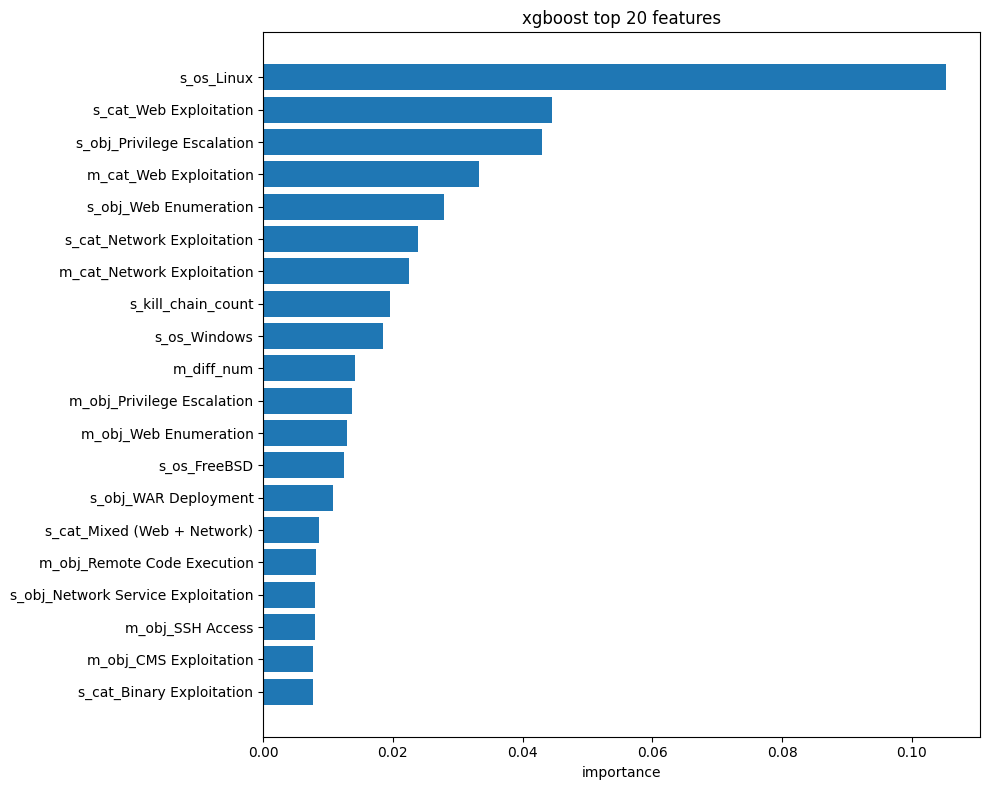

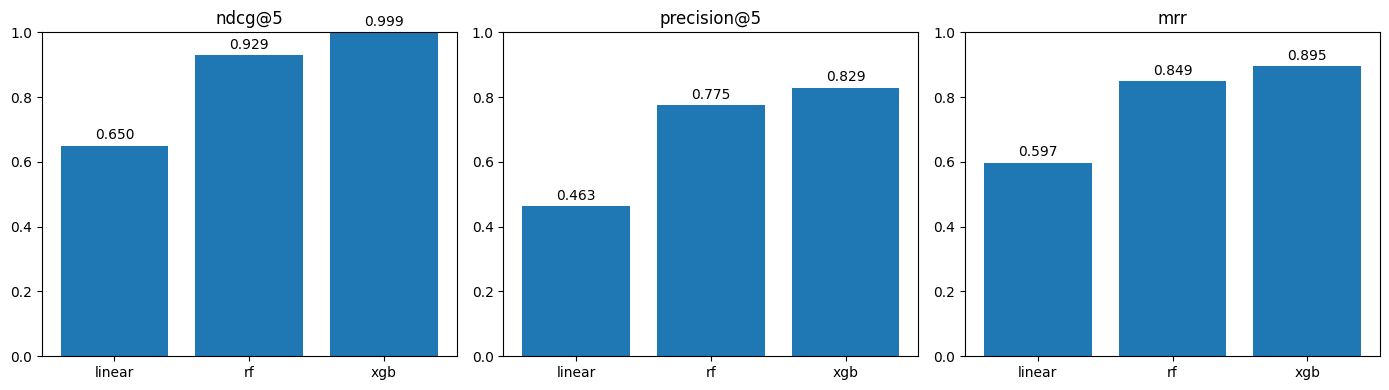


plots saved


In [13]:
# evaluating with proper recommender metrics 
# ndcg, precision@5, mrr (these measure ranking quality)

from sklearn.metrics import ndcg_score
import matplotlib.pyplot as plt

#compute the 3 ranking metrics per model
def get_ranking_metrics(model, test_df, X_test_full):
    preds = model.predict(X_test_full)
    eval_df = test_df.copy()
    eval_df['pred'] = preds
    
    ndcgs = []
    p5s = []
    mrrs = []
    
    for sid, group in eval_df.groupby('student_id'):
        if len(group) < 5:
            continue
        true_rel = group['relevance'].values
        pred_rel = group['pred'].values
        
        ndcgs.append(ndcg_score([true_rel], [pred_rel], k=5))
        
        top5 = np.argsort(pred_rel)[-5:]
        p5s.append((true_rel[top5] >= 0.5).mean())
        
        ranked = true_rel[np.argsort(pred_rel)[::-1]]
        rel_pos = np.where(ranked >= 0.5)[0]
        mrrs.append(1/(rel_pos[0]+1) if len(rel_pos) > 0 else 0)
    
    return np.mean(ndcgs), np.mean(p5s), np.mean(mrrs)


feature_cols_list = [c for c in training_data.columns if c not in ['student_id', 'machine_id', 'relevance']]
X_test_full = test_df[feature_cols_list].values

print("scoring all 3 models on test set, this takes a min...")

lr_n, lr_p, lr_m = get_ranking_metrics(lr_model, test_df, X_test_full)
rf_n, rf_p, rf_m = get_ranking_metrics(rf_model, test_df, X_test_full)
xgb_n, xgb_p, xgb_m = get_ranking_metrics(xgb_model, test_df, X_test_full)

# putting everything in a table
comparison = pd.DataFrame([
    ['Linear Regression', r2_score(y_test, y_test_pred_lr), mean_absolute_error(y_test, y_test_pred_lr), lr_n, lr_p, lr_m],
    ['Random Forest', r2_score(y_test, y_test_pred), mean_absolute_error(y_test, y_test_pred), rf_n, rf_p, rf_m],
    ['XGBoost', r2_score(y_test, y_test_pred_xgb), mean_absolute_error(y_test, y_test_pred_xgb), xgb_n, xgb_p, xgb_m],
], columns=['Model', 'R2', 'MAE', 'NDCG@5', 'Precision@5', 'MRR'])

print("\ncomparison:")
print(comparison.round(4))

comparison.to_csv(os.path.join(MODELS_DIR_V2, 'model_comparison.csv'), index=False)

#feature importance for xgboost
importance = pd.DataFrame({
    'feature': feature_cols_list,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\ntop 20 features xgboost used:")
print(importance.head(20))

# plot feature importance
plt.figure(figsize=(10,8))
top20 = importance.head(20)
plt.barh(range(20), top20['importance'].values[::-1])
plt.yticks(range(20), top20['feature'].values[::-1])
plt.xlabel('importance')
plt.title('xgboost top 20 features')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR_V2, 'plots', 'feature_importance.png'), dpi=120)
plt.show()

# bar chart comparing all 3 models
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
metrics_data = [
    ('ndcg@5', [lr_n, rf_n, xgb_n]),
    ('precision@5', [lr_p, rf_p, xgb_p]),
    ('mrr', [lr_m, rf_m, xgb_m])
]
for i, (name, vals) in enumerate(metrics_data):
    ax[i].bar(['linear', 'rf', 'xgb'], vals)
    ax[i].set_title(name)
    ax[i].set_ylim(0, 1)
    for j, v in enumerate(vals):
        ax[i].text(j, v+0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR_V2, 'plots', 'model_comparison.png'), dpi=120)
plt.show()

print("\nplots saved")

In [14]:
#testing xgboost on a real student profile to see what it recommends

def recommend_top5(diff, cats, os_pref, objs=None, time_pick=None, skill=None):
    svec = build_student_vector(diff, cats, os_pref, objs, time_pick, skill).values
    
    student_block = np.tile(svec, (n_machines, 1))
    X_inf = np.hstack([student_block, machine_features.values])
    
    scores = xgb_model.predict(X_inf)
    
    #sort by score descending, break ties with shorter attack path first
    order = np.lexsort((df['Attack_Path_Length'].values, -scores))
    top5_idx = order[:5]
    out = df.iloc[top5_idx][['Machine_Name', 'Difficulty', 'Attack_Category', 'OS', 'Estimated_Time', 'Attack_Path_Length']].copy()
    out['predicted_relevance'] = scores[top5_idx].round(3)
    return out

#test 1 -(easy web linux + sql injection)
print("test 1: Easy + Web + Linux + SQL Injection")
print(recommend_top5('Easy', ['Web Exploitation'], 'Linux', ['SQL Injection'], '1-2 hours', 'Beginner').to_string(index=False))

print("\ntest 2: Hard + Network + Linux + 2 objectives")
print(recommend_top5('Hard', ['Network Exploitation'], 'Linux', ['Privilege Escalation', 'SSH Access'], '3-4 hours', 'Advanced').to_string(index=False))

print("\ntest 3: Medium + Web + Linux + no objectives given")
print(recommend_top5('Medium', ['Web Exploitation'], 'Linux').to_string(index=False))

test 1: Easy + Web + Linux + SQL Injection
               Machine_Name Difficulty  Attack_Category    OS Estimated_Time  Attack_Path_Length  predicted_relevance
Pentester Lab SQLi to Shell       Easy Web Exploitation Linux      1-2 hours                   8                0.907
                    Freshly       Easy Web Exploitation Linux      1-2 hours                   7                0.899
              De-ICE S1.120       Easy Web Exploitation Linux      1-2 hours                   7                0.892
         LAMPSecurity CTF 4       Easy Web Exploitation Linux      1-2 hours                   6                0.885
         Kioptrix Level 1.2       Easy Web Exploitation Linux      1-2 hours                   6                0.884

test 2: Hard + Network + Linux + 2 objectives
 Machine_Name Difficulty      Attack_Category    OS Estimated_Time  Attack_Path_Length  predicted_relevance
De-ICE S1.140       Hard Network Exploitation Linux      3-4 hours                  12        

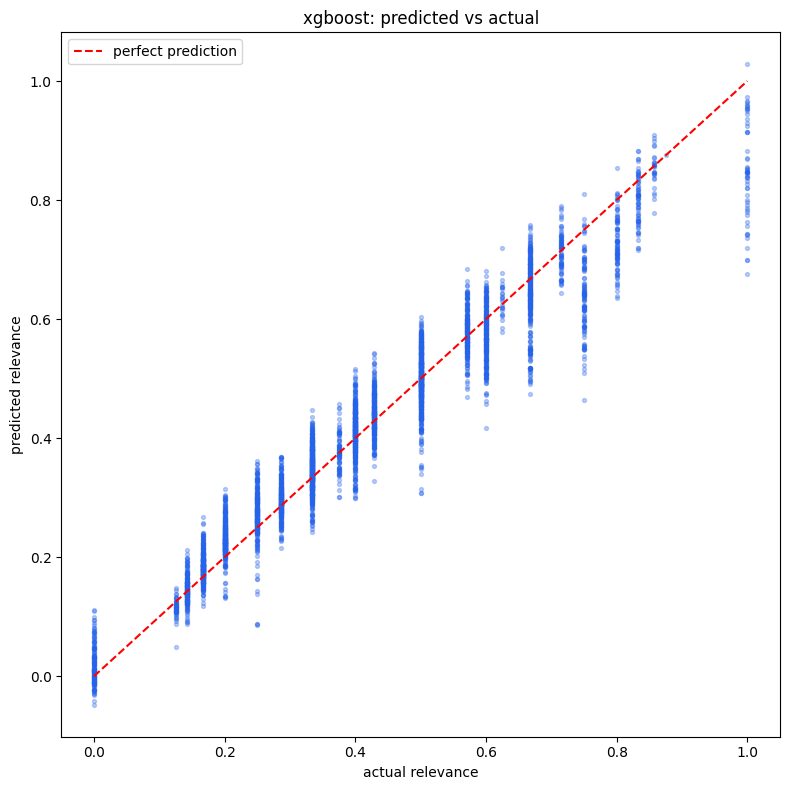

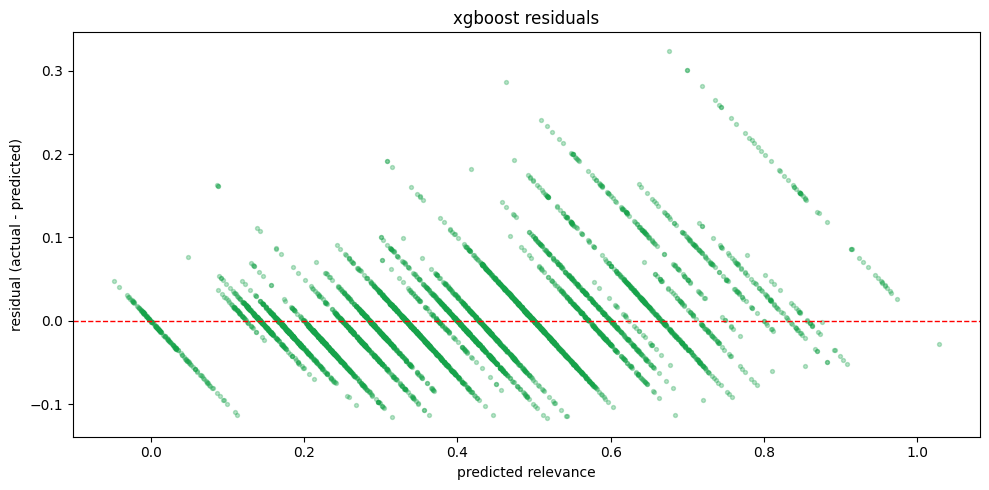

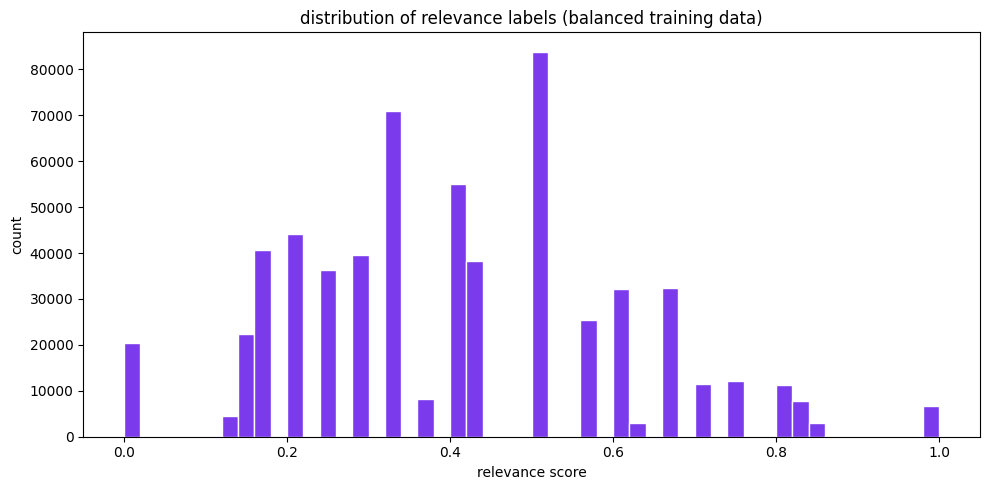

3 more plots saved to plots/


In [15]:
#plots  - predicted vs actual, residuals, distribution

# 1. predicted vs actual scatter (for xgboost)
plt.figure(figsize=(8, 8))
# subsample for cleaner plot since 122k points is too many
idx = np.random.choice(len(y_test), 5000, replace=False)
plt.scatter(y_test[idx], y_test_pred_xgb[idx], alpha=0.3, s=8, c='#2563eb')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='perfect prediction')
plt.xlabel('actual relevance')
plt.ylabel('predicted relevance')
plt.title('xgboost: predicted vs actual')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR_V2, 'plots', 'predicted_vs_actual.png'), dpi=120)
plt.show()

# 2. residual plot (true - predicted)
residuals = y_test - y_test_pred_xgb
plt.figure(figsize=(10, 5))
plt.scatter(y_test_pred_xgb[idx], residuals[idx], alpha=0.3, s=8, c='#16a34a')
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel('predicted relevance')
plt.ylabel('residual (actual - predicted)')
plt.title('xgboost residuals')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR_V2, 'plots', 'residuals.png'), dpi=120)
plt.show()

# 3. relevance distribution histogram
plt.figure(figsize=(10, 5))
plt.hist(training_data['relevance'], bins=50, color='#7c3aed', edgecolor='white')
plt.xlabel('relevance score')
plt.ylabel('count')
plt.title('distribution of relevance labels (balanced training data)')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR_V2, 'plots', 'relevance_distribution.png'), dpi=120)
plt.show()

print("3 more plots saved to plots/")

In [16]:
# 5 fold cross validation for xgboost


from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import time

print("running 5-fold cv on xgboost (sequential folds)...")
print("takes around 5-10 min")

start = time.time()

cv_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

# n_jobs=1 means run folds one at a time to save memory
cv_r2 = cross_val_score(cv_model, X, y, cv=5, scoring='r2', n_jobs=1)
cv_mae = -cross_val_score(cv_model, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=1)

elapsed = time.time() - start
print(f"\ndone in {elapsed/60:.1f} min")

print(f"\ncv r2 scores: {cv_r2.round(4)}")
print(f"cv r2 mean: {cv_r2.mean():.4f}")
print(f"cv r2 std:  {cv_r2.std():.4f}")

print(f"\ncv mae scores: {cv_mae.round(4)}")
print(f"cv mae mean: {cv_mae.mean():.4f}")
print(f"cv mae std:  {cv_mae.std():.4f}")

running 5-fold cv on xgboost (sequential folds)...
takes around 5-10 min

done in 5.5 min

cv r2 scores: [0.8579 0.8591 0.9119 0.8969 0.8977]
cv r2 mean: 0.8847
cv r2 std:  0.0221

cv mae scores: [0.0503 0.0488 0.0466 0.0482 0.0476]
cv mae mean: 0.0483
cv mae std:  0.0012


confusion matrix:
[[75743   444]
 [ 9547 36266]]

classification report:
              precision    recall  f1-score   support

not relevant       0.89      0.99      0.94     76187
    relevant       0.99      0.79      0.88     45813

    accuracy                           0.92    122000
   macro avg       0.94      0.89      0.91    122000
weighted avg       0.93      0.92      0.92    122000

roc auc: 0.9889


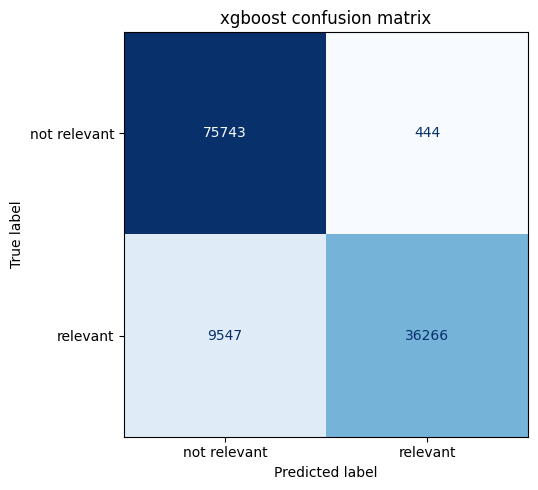

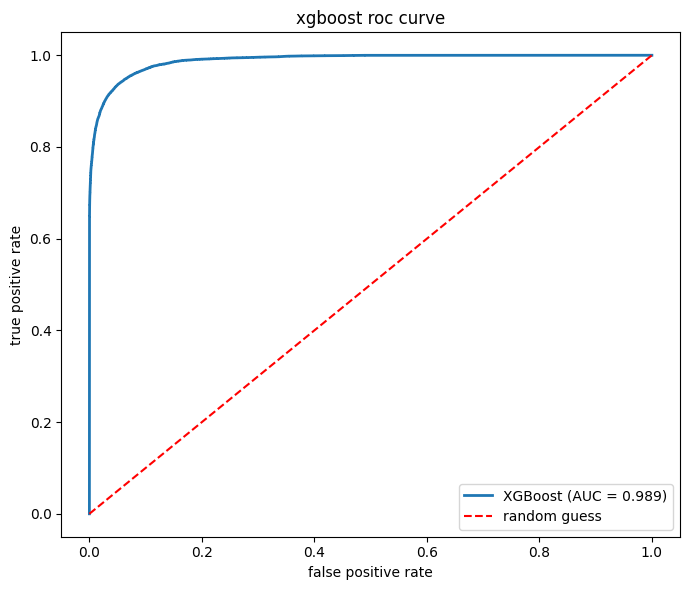

In [17]:
# converting regression to binary classification so we can do confusion matrix and roc
# a machine is "relevant" if its true relevance >= 0.5

from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, roc_auc_score, ConfusionMatrixDisplay)

# binary labels - is this machine truly relevant for this student
y_test_binary = (y_test >= 0.5).astype(int)

# binary predictions - did the model say relevant
y_pred_binary = (y_test_pred_xgb >= 0.5).astype(int)

# confusion matrix
cm = confusion_matrix(y_test_binary, y_pred_binary)
print("confusion matrix:")
print(cm)

print("\nclassification report:")
print(classification_report(y_test_binary, y_pred_binary, target_names=['not relevant', 'relevant']))

# auc score
auc = roc_auc_score(y_test_binary, y_test_pred_xgb)
print(f"roc auc: {auc:.4f}")

# plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not relevant', 'relevant'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('xgboost confusion matrix')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR_V2, 'plots', 'confusion_matrix.png'), dpi=120)
plt.show()

# plot roc curve
fpr, tpr, _ = roc_curve(y_test_binary, y_test_pred_xgb)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='random guess')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('xgboost roc curve')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR_V2, 'plots', 'roc_curve.png'), dpi=120)
plt.show()